<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/CNN_Flower.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Đọc data từ kaggle

In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\n  "username": "hoangdanghh",\n  "key": "KGAT_bce95034826acd32eabc1a214989b034"\n}'}

In [3]:
import os

# tạo thư mục kaggle
os.makedirs("/root/.kaggle", exist_ok=True)

# di chuyển file kaggle.json vào đúng chỗ
!cp kaggle.json /root/.kaggle/

# cấp quyền
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d alxmamaev/flowers-recognition

Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:01<00:00, 141MB/s]



In [5]:
!unzip flowers-recognition.zip -d flowers

Archive:  flowers-recognition.zip
  inflating: flowers/flowers/daisy/100080576_f52e8ee070_n.jpg  
  inflating: flowers/flowers/daisy/10140303196_b88d3d6cec.jpg  
  inflating: flowers/flowers/daisy/10172379554_b296050f82_n.jpg  
  inflating: flowers/flowers/daisy/10172567486_2748826a8b.jpg  
  inflating: flowers/flowers/daisy/10172636503_21bededa75_n.jpg  
  inflating: flowers/flowers/daisy/102841525_bd6628ae3c.jpg  
  inflating: flowers/flowers/daisy/10300722094_28fa978807_n.jpg  
  inflating: flowers/flowers/daisy/1031799732_e7f4008c03.jpg  
  inflating: flowers/flowers/daisy/10391248763_1d16681106_n.jpg  
  inflating: flowers/flowers/daisy/10437754174_22ec990b77_m.jpg  
  inflating: flowers/flowers/daisy/10437770546_8bb6f7bdd3_m.jpg  
  inflating: flowers/flowers/daisy/10437929963_bc13eebe0c.jpg  
  inflating: flowers/flowers/daisy/10466290366_cc72e33532.jpg  
  inflating: flowers/flowers/daisy/10466558316_a7198b87e2.jpg  
  inflating: flowers/flowers/daisy/10555749515_13a12a026e.jpg

In [6]:
import os

base_dir = "/content/flowers"

for folder in os.listdir(base_dir):
    print(folder, ":", len(os.listdir(os.path.join(base_dir, folder))))

flowers : 5


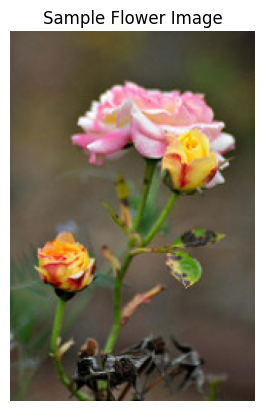

In [8]:
import matplotlib.pyplot as plt
import cv2
import os

sample_path = "/content/flowers/flowers/rose"
img_name = os.listdir(sample_path)[0]

img = cv2.imread(os.path.join(sample_path, img_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Flower Image")
plt.axis("off")
plt.show()

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 3454 images belonging to 1 classes.
Found 863 images belonging to 1 classes.
